In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# MovieLens scaling

Reader-facing companion for the MovieLens 20M one-pass scaling experiment. Its purpose is to test whether spectral neurons train and benefit from greater matrix dimension as the number of observed ratings grows. FM is the parameter-matched capacity reference; this is not a recommender-system leaderboard study. Lower RMSE is better.

## Setup

In [2]:
import os
import warnings
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd

from paper.experiments.movielens_scaling import (
    PROFILES,
    default_raw_path,
    select_lr,
    summarize_raw,
    validate_raw,
)
from paper.plotting import (
    plot_movielens_dimensions,
    plot_movielens_models_by_dimension,
    plot_movielens_warm_coverage,
)

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = os.environ.get("MOVIELENS_SCALING_PROFILE", "full")
variant = os.environ.get("MOVIELENS_SCALING_VARIANT") or None
profile = PROFILES[profile_name]

raw_override = os.environ.get("MOVIELENS_SCALING_RAW_PATH")
raw_path = (
    Path(raw_override)
    if raw_override
    else default_raw_path(profile_name, variant)
)

## Context and assumptions

- The source is the [MovieLens 20M dataset](https://grouplens.org/datasets/movielens/20m/). The fixed split is random 80/10/10 within each user; one holdout rating is moved into training for any movie otherwise absent from the complete training pool.
- Users and movies are compact categorical IDs, so there is no fitted feature preprocessing. Ratings are shifted by the fixed midpoint 2.75 during training; RMSE is unchanged and remains in rating units.
- Each data seed permutes that complete training pool. A trajectory consumes nested prefixes of one permutation, so the x-axis is ratings seen by the optimizer—not independently trained datasets or convergence-controlled fits.
- Validation RMSE at the final checkpoint selects one learning rate per model family and capacity. Evaluation then initializes a fresh model and reports test RMSE along one coherent trajectory.
- With one user and one movie field, FM is exactly biased matrix factorization. For spectral dimension $d$, both nonlinear families use $d(d+1)/2$ parameters per identity: one FM bias plus rank $d(d+1)/2-1$, versus one symmetric $d\times d$ matrix. Spectral uses the middle eigenvalue, $\lambda_{d // 2}$, and the profiles therefore use odd dimensions.
- Lines are medians across data-order and initialization seeds. Bands span the interquartile seed variation on one fixed test set; they are not confidence intervals for a test population.

## Load and validate results

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; "
        "run paper.experiments.movielens_scaling first"
    )

raw = pd.read_csv(raw_path)
validate_raw(raw, profile, variant)

## Validation selection and recorded capacity

In [5]:
selected = select_lr(raw)
selected_lrs = selected[
    ["model", "dim", "rank", "parameters_per_identity", "selected_lr"]
].drop_duplicates()
boundaries = selected_lrs.loc[
    np.isclose(selected_lrs["selected_lr"], min(profile.lrs))
    | np.isclose(selected_lrs["selected_lr"], max(profile.lrs))
]
if not boundaries.empty:
    warnings.warn(
        "selected learning rate touches the tuning-grid boundary for:\n"
        + boundaries.to_string(index=False),
        stacklevel=1,
    )

capacity_table = (
    selected[
        [
            "model",
            "dim",
            "rank",
            "parameters_per_identity",
            "num_parameters",
        ]
    ]
    .drop_duplicates()
    .sort_values(["dim", "model"], kind="stable")
    .reset_index(drop=True)
)
capacity_table

,model,dim,rank,parameters_per_identity,num_parameters
0,linear,0,0,1,165238
1,fm,3,5,6,991423
2,spectral,3,0,6,991428
3,fm,7,27,28,4626637
4,spectral,7,0,28,4626664
5,fm,11,65,66,10905643
6,spectral,11,0,66,10905708


## Selected test summary

In [6]:
summary = summarize_raw(raw)
summary[
    [
        "train_size",
        "model",
        "dim",
        "rank",
        "parameters_per_identity",
        "num_parameters",
        "selected_lr",
        "median_test_rmse",
        "q25_test_rmse",
        "q75_test_rmse",
        "median_test_warm_fraction",
        "n",
    ]
].sort_values(["train_size", "dim", "model"], kind="stable")

,train_size,model,dim,rank,parameters_per_identity,num_parameters,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,median_test_warm_fraction,n
15,1048576,linear,0,0,1,165238,0.006310,0.936026,0.936008,0.936045,0.976519,8
0,1048576,fm,3,5,6,991423,0.006310,0.934451,0.934185,0.934840,0.976519,8
20,1048576,spectral,3,0,6,991428,0.006310,0.997540,0.996579,0.999282,0.976519,8
5,1048576,fm,7,27,28,4626637,0.006310,0.930233,0.929629,0.930735,0.976519,8
25,1048576,spectral,7,0,28,4626664,0.006310,0.981311,0.980495,0.981990,0.976519,8
10,1048576,fm,11,65,66,10905643,0.002512,0.983326,0.982951,0.983629,0.976519,8
30,1048576,spectral,11,0,66,10905708,0.006310,0.970285,0.970102,0.970570,0.976519,8
16,2097152,linear,0,0,1,165238,0.006310,0.905292,0.905182,0.905402,0.994937,8
1,2097152,fm,3,5,6,991423,0.006310,0.895182,0.892356,0.896694,0.994937,8
21,2097152,spectral,3,0,6,991428,0.006310,0.946150,0.945527,0.947300,0.994937,8


## Spectral neurons across dimensions

This is the central capacity-scaling view for the paper: it asks whether larger learned matrices become useful as more ratings are observed.

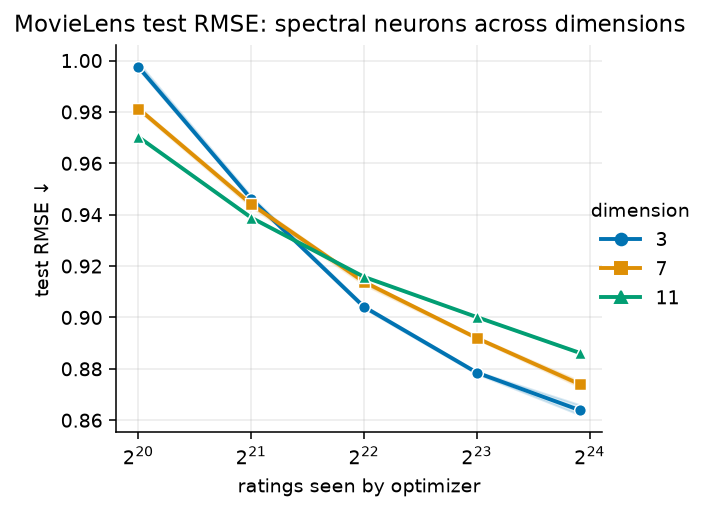

In [7]:
if variant in (None, "spectral"):
    plot_movielens_dimensions(selected, "spectral")
else:
    print(
        "Spectral-dimension comparison requires the merged result "
        "or the spectral shard."
    )

## Matched model families within each dimension

Each facet fixes the spectral dimension and per-identity parameter budget. The same linear trajectory is repeated as a common reference.

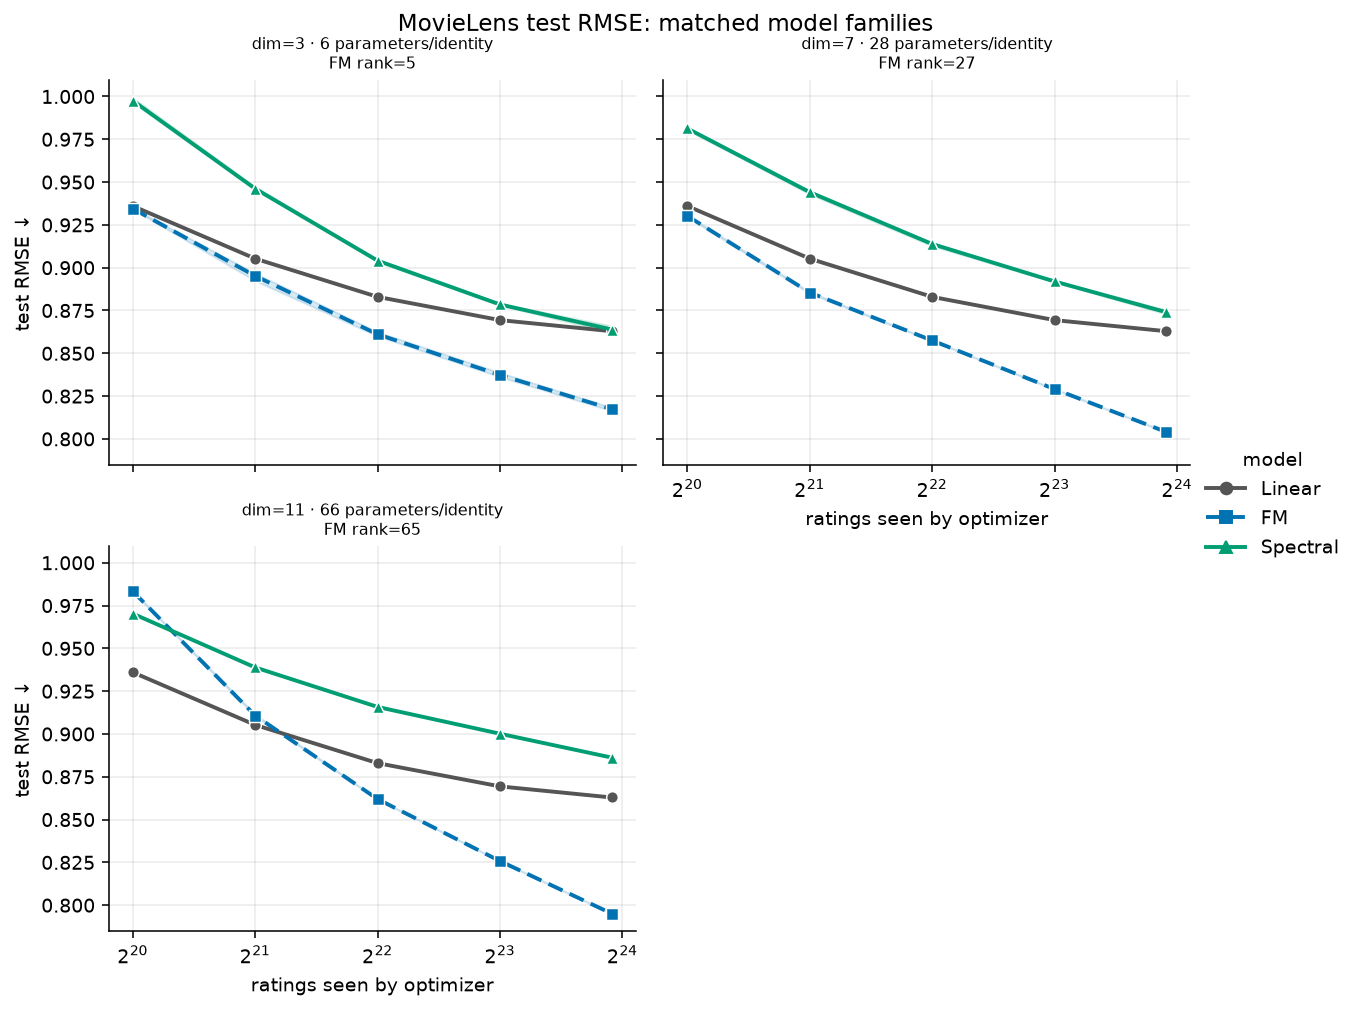

In [8]:
if variant is None:
    plot_movielens_models_by_dimension(selected)
else:
    print(
        "Matched-family facets require the merged result; "
        "set variant=None after appending all family shards."
    )

## FM across embedding ranks

The corresponding matrix-factorization view shows whether this dataset and training protocol expose a capacity effect in a familiar model family.

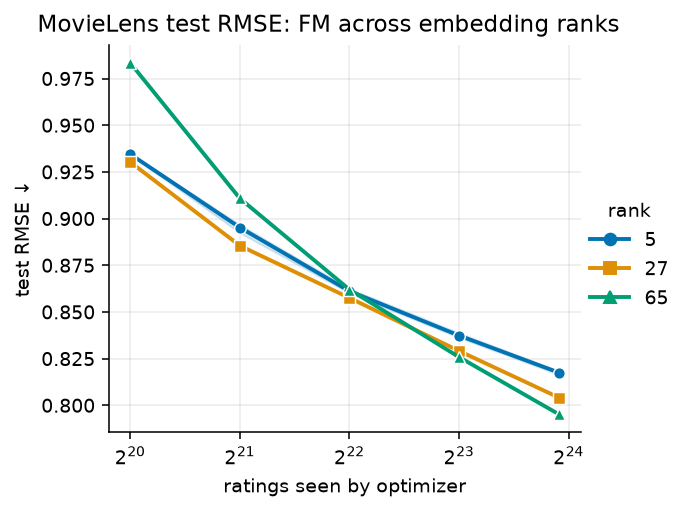

In [9]:
if variant in (None, "fm"):
    plot_movielens_dimensions(selected, "fm")
else:
    print(
        "FM rank comparison requires the merged result or the FM shard."
    )

## Prefix warm coverage

A validation or test identity is guaranteed to occur somewhere in the complete training pool, but it may not yet have occurred in an early random prefix. This diagnostic shows how much of the fixed test set is warm at each checkpoint; test RMSE itself is always computed on the complete fixed test set.

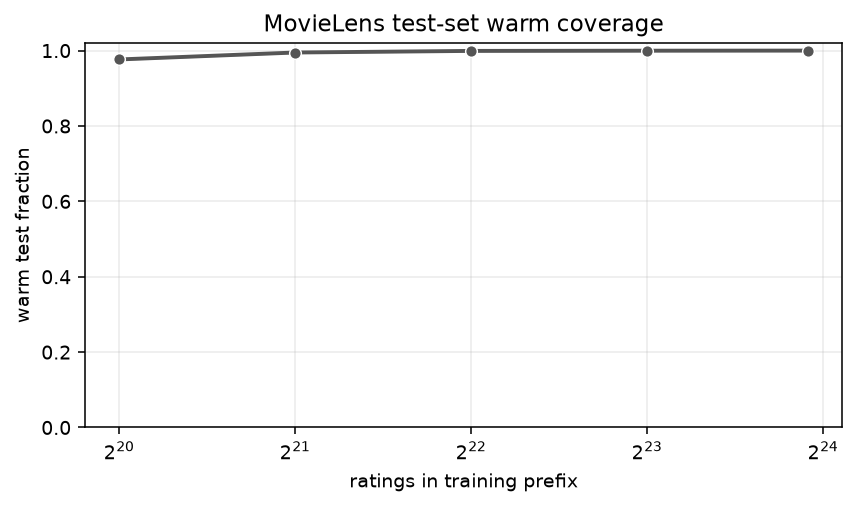

In [10]:
plot_movielens_warm_coverage(selected);

## Reading the figures

The matched facets compare model families at a fixed per-identity capacity. The one-axis spectral plot is the primary test of whether the spectral family improves with dimension; the FM plot is a capacity-sensitive reference. The coverage plot should be read first when interpreting early checkpoints, because differences there can include behavior on identities not yet observed by the optimizer.

Write substantive empirical conclusions here only after this notebook has executed against the complete result file.